# Advección 1D de Campo Magnético

Este cuaderno resuelve la ecuación de advección 1D para un campo magnético $B$, que representa una demostración mínima del *flux freezing* (congelamiento del flujo) en magnetohidrodinámica (MHD) unidimensional.

La ecuación de gobierno es:
$$ \frac{\partial B}{\partial t} + v_0 \frac{\partial B}{\partial x} = 0 $$

### Esquema Numérico (Upwind Explícito)
Para discretizar esta ecuación, utilizamos un esquema *upwind* (aguas arriba) explícito, implementado con diferencias finitas hacia atrás, asumiendo una velocidad de advección $v_0 > 0$:

$$ B_i^{n+1} = B_i^n - \left( \frac{v_0 \Delta t}{\Delta x} \right) (B_i^n - B_{i-1}^n) $$

La estabilidad de este método está dictada por la **Condición CFL (Courant-Friedrichs-Lewy)**:
$$ C = \frac{v_0 \Delta t}{\Delta x} \le 1 $$

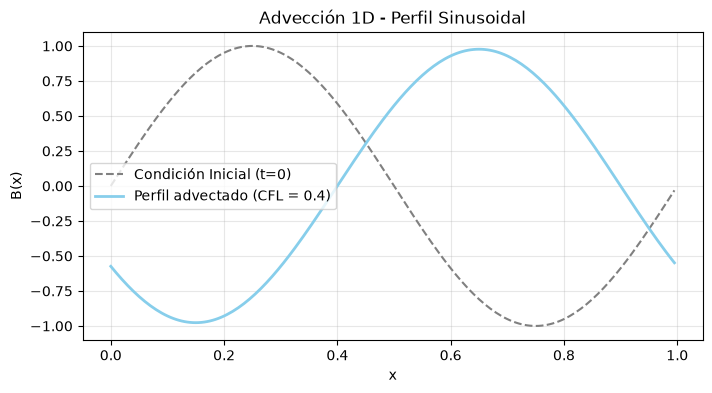

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simular_adveccion(CFL, perfil='seno', N=200, iteraciones=200):
    """
    Simula la advección 1D de un campo magnético usando el esquema upwind.
    """
    # Parámetros físicos y espaciales
    L = 1.0
    v0 = 1.0
    dx = L / N
    dt = CFL * dx / v0
    x = np.linspace(0, L, N, endpoint=False)
    
    # Condición inicial
    if perfil == 'seno':
        B_inicial = np.sin(2 * np.pi * x / L)
    elif perfil == 'gaussiano':
        # Pulso gaussiano centrado en L/2
        sigma = 0.05
        B_inicial = np.exp(-0.5 * ((x - L/2) / sigma)**2)
        
    B = np.copy(B_inicial)
    
    # Bucle de integración temporal
    for _ in range(iteraciones):
        # np.roll(B, 1) desplaza el arreglo un índice a la derecha, 
        # implementando mágicamente la frontera periódica B_{i-1}
        backward = B - np.roll(B, 1)
        B += -(v0 * dt / dx) * backward
        
    return x, B_inicial, B

# 1. Prueba base solicitada en la guía (CFL = 0.4)
x, B_ini, B_fin = simular_adveccion(CFL=0.4)

plt.figure(figsize=(8, 4))
plt.plot(x, B_ini, '--', color='gray', label='Condición Inicial (t=0)')
plt.plot(x, B_fin, color='skyblue', linewidth=2, label='Perfil advectado (CFL = 0.4)')
plt.title('Advección 1D - Perfil Sinusoidal')
plt.xlabel('x')
plt.ylabel('B(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Análisis de Resultados: Efecto de la Condición CFL

**1. ¿Cómo es el perfil de la onda?**
Se observa que la onda se desplaza a la velocidad $v_0$ (advección física). Sin embargo, el esquema *upwind* de primer orden introduce un error de truncamiento que actúa matemáticamente como un término de difusión. Como resultado, **el perfil sufre difusión numérica (amortiguamiento artificial)**: la onda pierde amplitud y se ensancha ligeramente con respecto a la condición inicial.

**2. ¿Cómo es el perfil si CFL es cercano a cero y si es cercano a 1?**
El término de difusión numérica artificial en el esquema upwind es proporcional a $v_0 \Delta x (1 - C) / 2$.
*   **Si CFL $\rightarrow$ 0:** El factor $(1 - C)$ es máximo. La difusión numérica es severa y la amplitud de la onda decae drásticamente tras varias iteraciones.
*   **Si CFL $\rightarrow$ 1:** El factor $(1 - C)$ tiende a cero. La difusión numérica desaparece y el esquema se vuelve exacto. El perfil se traslada sin perder su forma ni su amplitud original.

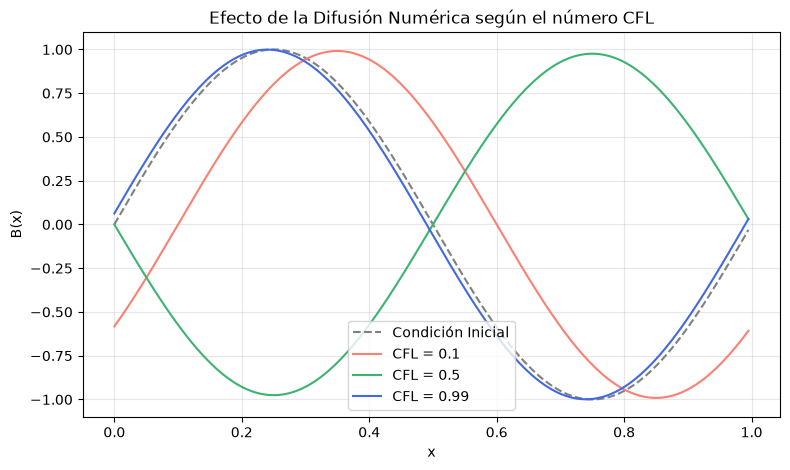

In [3]:
# Comparación de diferentes valores de CFL permitidos
cfl_values = [0.1, 0.5, 0.99]
colores = ['salmon', 'mediumseagreen', 'royalblue']

plt.figure(figsize=(9, 5))
plt.plot(x, B_ini, '--', color='gray', label='Condición Inicial')

for cfl, color in zip(cfl_values, colores):
    _, _, B_res = simular_adveccion(CFL=cfl)
    plt.plot(x, B_res, color=color, label=f'CFL = {cfl}')

plt.title('Efecto de la Difusión Numérica según el número CFL')
plt.xlabel('x')
plt.ylabel('B(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Inestabilidad Numérica

**3. ¿Qué pasa con el perfil cuando CFL > 1?**
La condición de Courant-Friedrichs-Lewy (CFL) dicta que la distancia física que viaja la información en un paso de tiempo ($v_0 \Delta t$) no puede ser mayor que el tamaño de la celda de la malla ($\Delta x$). Si $C > 1$, la onda se mueve más rápido de lo que la malla puede resolver, violando el dominio de dependencia matemático. 

El resultado es una **inestabilidad numérica catastrófica**: los errores de redondeo se amplifican exponencialmente y el perfil "explota" hacia el infinito.

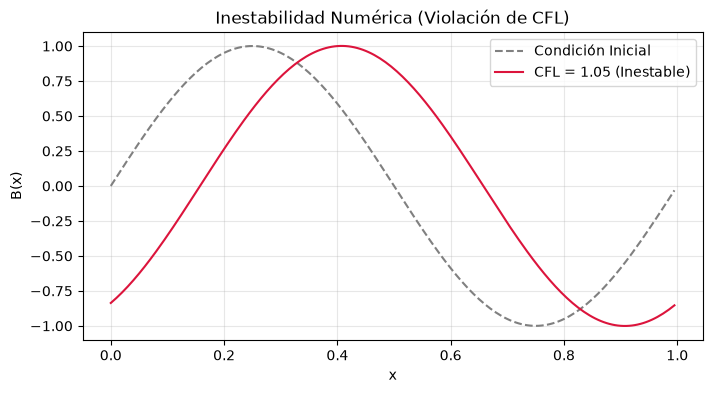

In [4]:
# Prueba de Inestabilidad (CFL = 1.05)
# Reducimos iteraciones porque el crecimiento exponencial da error de desbordamiento (overflow) rápido
x, B_ini_inest, B_inestable = simular_adveccion(CFL=1.05, iteraciones=30)

plt.figure(figsize=(8, 4))
plt.plot(x, B_ini_inest, '--', color='gray', label='Condición Inicial')
plt.plot(x, B_inestable, color='crimson', label='CFL = 1.05 (Inestable)')
plt.title('Inestabilidad Numérica (Violación de CFL)')
plt.xlabel('x')
plt.ylabel('B(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Pulso Gaussiano

**4. ¿Cómo cambia si hay un pulso gaussiano en lugar de sinusoidal?**
La física del problema y el comportamiento del esquema numérico son exactamente los mismos, pero la visualización del error cambia. Un pulso gaussiano contiene un espectro más amplio de frecuencias espaciales (armónicos). La difusión numérica afecta más fuertemente a las altas frecuencias, por lo que observaremos cómo **el pico del pulso se achata (pierde altura rápidamente) y sus bases se ensanchan**, demostrando de forma más intuitiva el "desparramamiento" provocado por el esquema *upwind*.

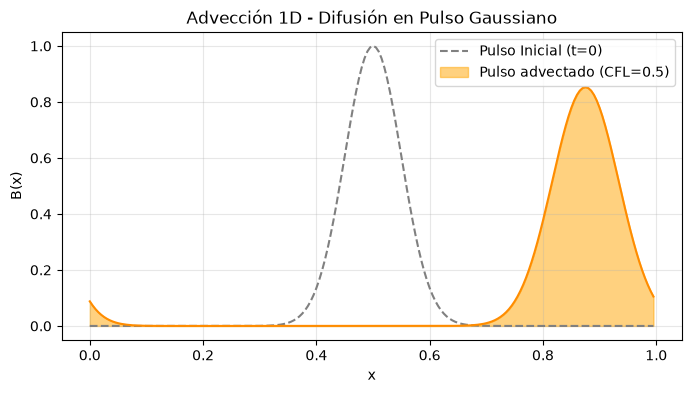

In [5]:
# Prueba con pulso gaussiano (usando un CFL intermedio para ver la difusión)
x, B_gauss_ini, B_gauss_fin = simular_adveccion(CFL=0.5, perfil='gaussiano', iteraciones=150)

plt.figure(figsize=(8, 4))
plt.plot(x, B_gauss_ini, '--', color='gray', label='Pulso Inicial (t=0)')
plt.fill_between(x, B_gauss_fin, color='orange', alpha=0.5, label='Pulso advectado (CFL=0.5)')
plt.plot(x, B_gauss_fin, color='darkorange')
plt.title('Advección 1D - Difusión en Pulso Gaussiano')
plt.xlabel('x')
plt.ylabel('B(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5. Comparación Numérica vs. Solución Analítica

La solución matemática exacta (analítica) de la ecuación de advección unidimensional $\partial B / \partial t + v_0 \partial B / \partial x = 0$ con velocidad constante es una simple traslación espacial de la condición inicial:

$$ B_{\text{exacto}}(x, t) = B(x - v_0 t, 0) $$

Dado que el problema tiene fronteras periódicas en un dominio de longitud $L$, la posición exacta de cualquier punto de la onda en el tiempo $t$ se puede calcular desplazando la coordenada original y aplicando el operador módulo ($x \pmod L$).

A continuación, validamos nuestro esquema numérico de **Diferencias Finitas (FDM)** contrastando el perfil final advectado contra el perfil matemático exacto calculado para el mismo instante de tiempo final.

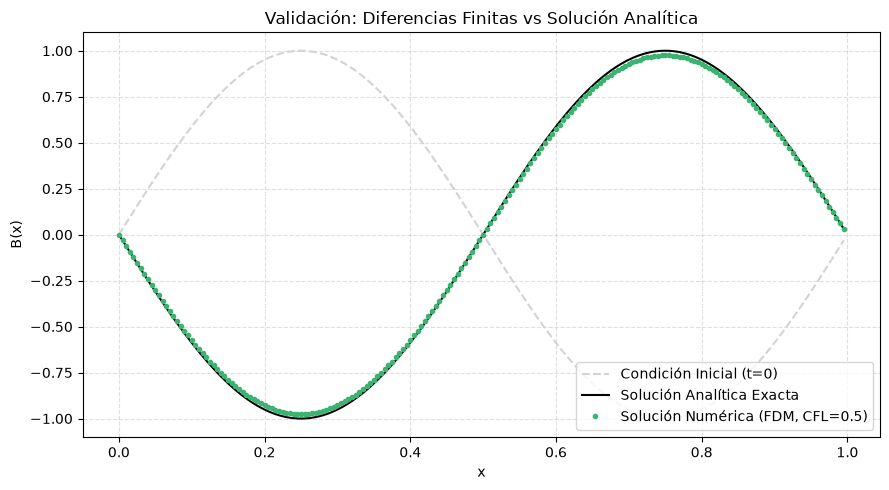

In [6]:
# ==========================================
# 5. Comparación Analítica vs Numérica (FDM)
# ==========================================

# Parámetros para la prueba
CFL_test = 0.5
iteraciones_test = 200
N_nodos = 200
L_dom = 1.0
v0_vel = 1.0

# Calculamos el tiempo físico total simulado
dx_test = L_dom / N_nodos
dt_test = CFL_test * dx_test / v0_vel
tiempo_final = iteraciones_test * dt_test

# 1. Obtenemos la solución numérica con la función que ya creamos
x_test, B_ini_base, B_numerico = simular_adveccion(CFL=CFL_test, N=N_nodos, iteraciones=iteraciones_test)

# 2. Construimos la solución analítica exacta en t = tiempo_final
# Restamos la distancia recorrida (v0 * t) y aplicamos módulo L para la periodicidad
x_desplazado = (x_test - v0_vel * tiempo_final) % L_dom
B_analitico = np.sin(2 * np.pi * x_desplazado / L_dom)

# 3. Graficamos la comparativa
plt.figure(figsize=(9, 5))

# Condición inicial (referencia visual)
plt.plot(x_test, B_ini_base, '--', color='lightgray', label='Condición Inicial (t=0)')

# Solución Analítica (Línea continua)
plt.plot(x_test, B_analitico, '-', color='black', linewidth=1.5, label='Solución Analítica Exacta')

# Solución Numérica FDM (Puntos superpuestos para ver la discretización)
plt.plot(x_test, B_numerico, 'o', color='mediumseagreen', markersize=3, 
         label=f'Solución Numérica (FDM, CFL={CFL_test})')

plt.title('Validación: Diferencias Finitas vs Solución Analítica')
plt.xlabel('x')
plt.ylabel('B(x)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

El desarrollo de este ejercicio numérico sobre la advección unidimensional de un campo magnético permite establecer las siguientes conclusiones fundamentales sobre los esquemas de integración en Astrofísica Computacional:

*   **Validación de la Condición de Estabilidad (CFL):** Se demostró empíricamente que la condición de Courant-Friedrichs-Lewy ($C \le 1$) es un límite estricto y no negociable para la estabilidad de esquemas explícitos. Al superarla ($C > 1$), el dominio de dependencia numérico no logra abarcar el dominio físico, lo que desencadena una amplificación exponencial de los errores de truncamiento de alta frecuencia (inestabilidad catastrófica).
*   **Naturaleza Disipativa del Esquema Upwind:** El método de diferencias finitas *upwind* de primer orden es robusto y evita oscilaciones espurias cerca de discontinuidades, pero introduce una fuerte **difusión numérica**. Este amortiguamiento artificial actúa matemáticamente como un término de viscosidad que degrada la amplitud de las ondas a lo largo del tiempo.
*   **Sensibilidad a las Frecuencias Espaciales:** La comparación entre el perfil sinusoidal y el pulso gaussiano evidenció que la difusión numérica penaliza de manera mucho más severa a los gradientes pronunciados (altas frecuencias espaciales). Los picos agudos se achatan y ensanchan rápidamente, lo cual es crítico al simular frentes de choque astronómicos.
*   **Dependencia del Error con el paso de integración:** El error difusivo del esquema es proporcional a $(1 - C)$. Por lo tanto, operar con un número CFL cercano a 1 minimiza la difusión artificial y aproxima mejor la solución numérica a la analítica. Sin embargo, en simulaciones MHD reales y multidimensionales, las velocidades locales varían, obligando a usar valores de CFL más conservadores (ej. $C \approx 0.4 - 0.8$) y asumiendo inevitablemente un grado de disipación.
*   **Necesidad de Esquemas de Alto Orden:** La divergencia observada entre la solución analítica exacta (conservación perfecta) y la solución numérica (decaimiento difusivo) justifica la necesidad de implementar esquemas de orden superior en el tiempo y el espacio (como métodos de tipo Lax-Wendroff, Runge-Kutta o reconstructores de TVD/WENO) para simulaciones magnetohidrodinámicas de alta fidelidad.